
# **Türkiye Ulusal Gözlemevleri Bünyesindeki Erzurum DAG Yerleşkesi ve Antalya TUG Yerleşkesi için Gece Işıklarının Analizi**

## **Eğitim ve Uygulama Serisi - Bölüm 6: VIIRS NTL Verilerinden Değişim Tespiti Analizleri**

- Bu eğitim serisi, **TÜBİTAK** 3501 Kariyer Geliştirme Programı kapsamında desteklenen **"124F297"** numaralı proje çerçevesinde geliştirilmiştir.

- **Dokümanı Hazırlayanlar: Dr. Kazım Kaba, Dr. Funda Aksoy, Doç. Dr. İlham Nasıroğlu, Fethullah Polat, Sima Aydın, Rabia Beyza Türkmen, Yusuf Sağlam, Prof. Dr. Cahit Yeşilyaprak, Prof. Dr. H. Mustafa Kandırmaz**

- Bu uygulama dosyasında; kentsel aydınlatma havzalarının yıllar içerisindeki mekânsal büyüme ve gerileme bölgelerini doğrudan haritalandırmak amacıyla **Değişim Tespiti Analizleri (Change Detection Analysis - CDA)** gerçekleştireceğiz. Bu yöntem, ışık kirliliğinin coğrafi olarak hangi bölgelerde yoğunlaştığını görsel ve sayısal olarak ortaya koyacaktır.



## **6.1 VIIRS NTL Verilerinden Mekânsal Değişim Tespiti Analizi**

- Bir önceki bölümde uyguladığımız zaman serisi analizleri, ışık kirliliğinin ulusal ve bölgesel ölçeklerdeki kümülatif artış hızını (ivmesini) matematiksel olarak sunmuştur. Ancak istatistiksel trendler, kentsel aydınlanmanın veya karartmanın coğrafi olarak hangi bölgelerde, hangi koridorlar boyunca ve ne yöne doğru hareket ettiğini mekânsal olarak gösteremez.

- Bu mekânsal boşluğu doldurmak amacıyla, uzaktan algılama literatüründe standart bir yöntem olan **"görüntüler arası fark (image differencing)"** tekniğini uygulayarak değişim tespiti analizi gerçekleştireceğiz.

- Bu bölümde; kar yansımasından arındırılmış veri setimiz olan **"NearNadir_Composite_Snow_Free"** yıllık kompozitlerini kullanarak, piksellerin yıllar içerisindeki matematiksel farkını hesaplayacağız. Analizi, kentsel aydınlatma teknolojilerindeki yapısal dönüşümleri ve gözlemevlerini tehdit eden büyüme dinamiklerini yakalayabilmek için 4 ayrı zaman diliminde kurguladık:

    - Dönem 1 (2012 - 2017): İlk 5 Yıllık Kısa Vadeli Değişim
    
    - Dönem 2 (2017 - 2022): İkinci 5 Yıllık Orta Vadeli Değişim
    
    - Dönem 3 (2022 - 2025): Son 3 Yıllık Güncel Değişim
    
    - Toplam Değişim (2012 - 2025): 14 Yıllık Kümülatif Değişim

- Aşağıdaki Python kodu; belirlediğimiz bu periyotlardaki uydu haritalarını üst üste bindirecek, arka plan gürültülerini (Nodata) filtreleyerek piksel piksel çıkarma işlemini uygulayacak ve elde edilen fark matrislerini **kırmızı (aydınlanma/artış)** ve **mavi (karartma/azalış)** renk kodlarıyla haritalandıracaktır.


DEĞİŞİM TESPİTİ VE HARİTALAMA İŞLEMİ BAŞLATILDI
--------------------------------------------------------------------------------

--- TURKIYE BÖLGESİ İŞLENİYOR ---


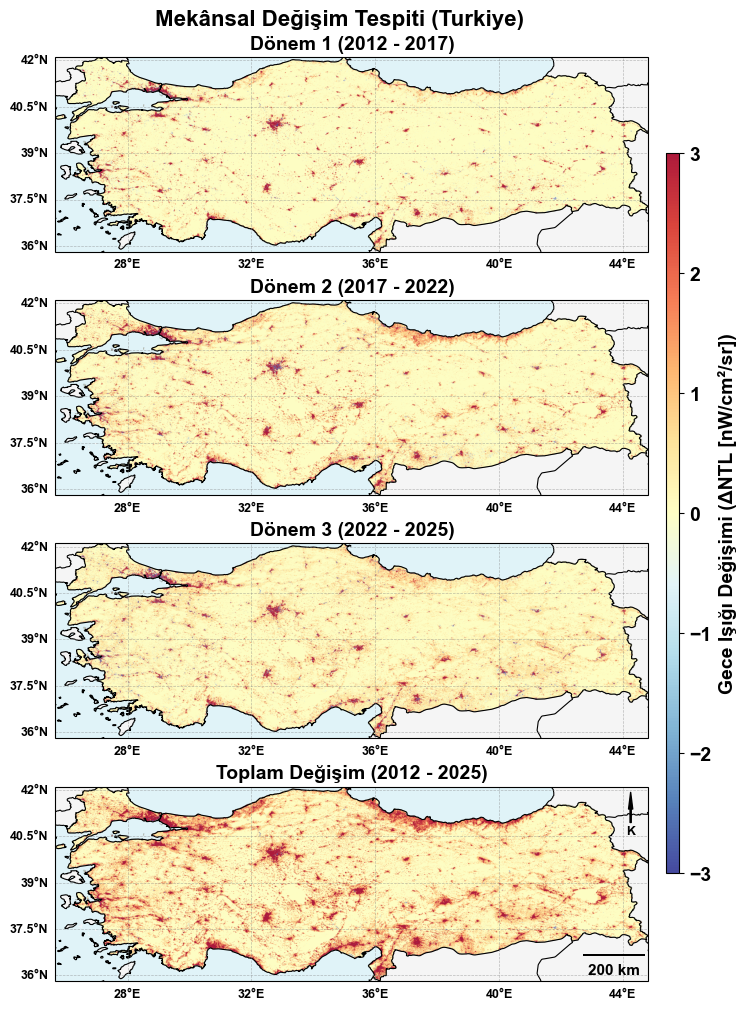

HARİTA ÇİZİLDİ: Turkiye -> SONUC_RAPORU_NTL_CDA_01_map_Turkiye.png

--- ANTALYA BÖLGESİ İŞLENİYOR ---


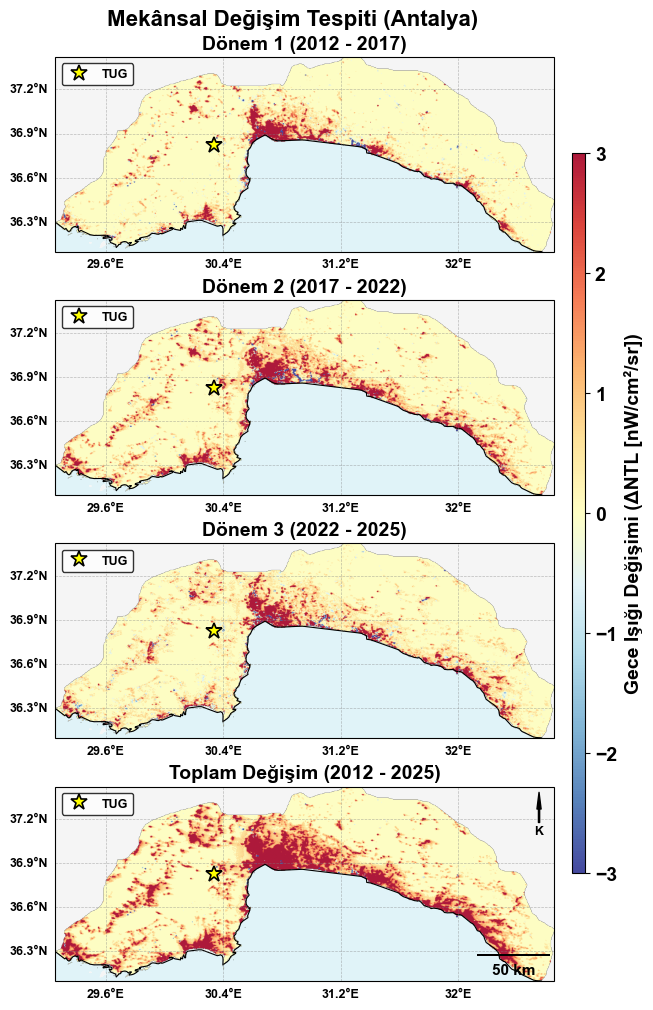

HARİTA ÇİZİLDİ: Antalya -> SONUC_RAPORU_NTL_CDA_01_map_Antalya.png

--- ERZURUM BÖLGESİ İŞLENİYOR ---


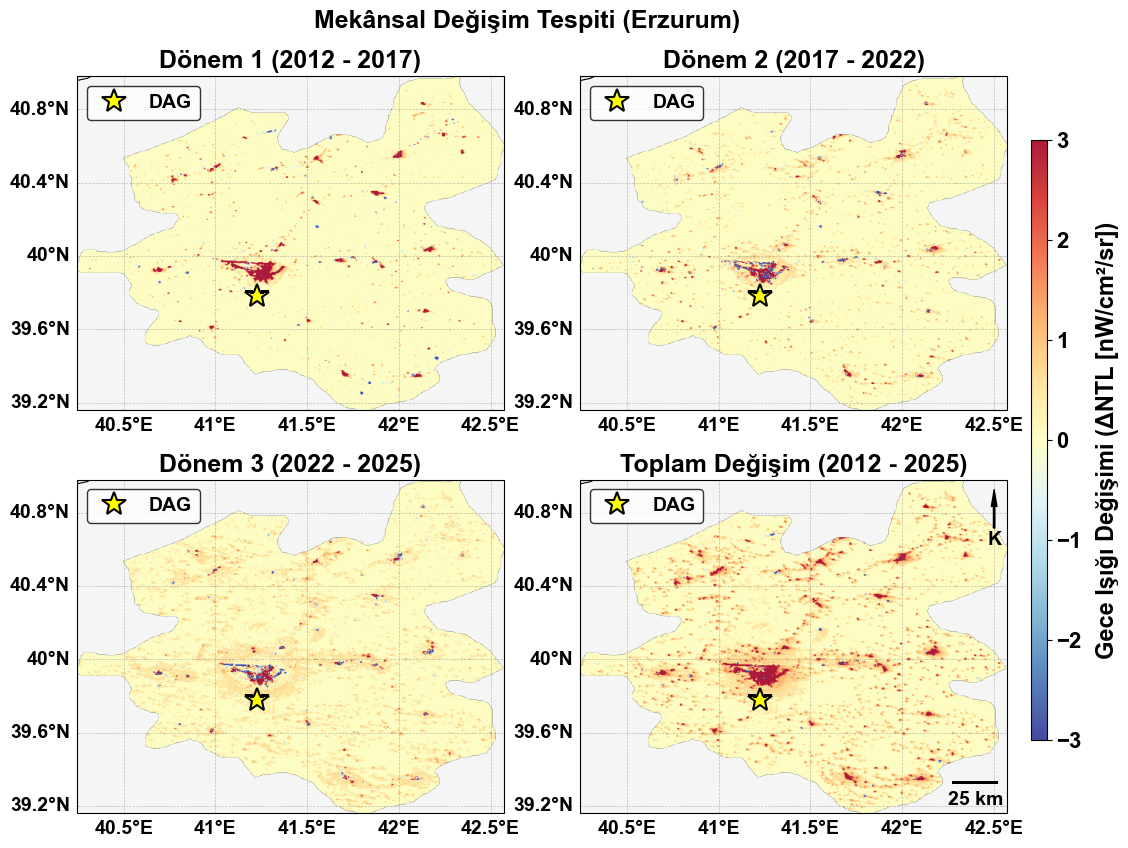

HARİTA ÇİZİLDİ: Erzurum -> SONUC_RAPORU_NTL_CDA_01_map_Erzurum.png

Tüm Değişim Tespiti haritaları başarıyla oluşturuldu ve kaydedildi.


In [1]:

# Gerekli modülleri içe aktarıyoruz
import os
import glob
import rasterio
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib_scalebar.scalebar import ScaleBar
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker
import warnings
# Uyarı mesajlarını kapatıyoruz
warnings.filterwarnings('ignore')

# ==========================================
# GÖRSEL AYARLAR (rcParams)
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Helvetica', 'sans-serif']
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['font.size'] = 14              # Genel varsayılan yazı boyutu
plt.rcParams['font.weight'] = 'bold'         # Genel kalın yazı
plt.rcParams['axes.labelsize'] = 14          # Eksen etiketleri boyutu
plt.rcParams['axes.titlesize'] = 14          # Alt grafik başlıkları boyutu
plt.rcParams['xtick.labelsize'] = 14         # X koordinat tick boyutları
plt.rcParams['ytick.labelsize'] = 14         # Y koordinat tick boyutları
plt.rcParams['legend.fontsize'] = 14         # Lejant yazı boyutu
plt.rcParams['figure.titlesize'] = 16        # Ana figür başlığı boyutu

# Gözlemevi Koordinatları
gozlemevleri = {
    'Antalya': {'isim': 'TUG', 'lon': 30.335452, 'lat': 36.824152},
    'Erzurum': {'isim': 'DAG', 'lon': 41.226402, 'lat': 39.780420}
}

# ==========================================
# 1. AŞAMA: FARK HESABI (GEOTIFF) ÜRETİMİ
# ==========================================
def fark_verisi_uret(kaynak_klasor, cikti_klasoru, bolge_adi, katman_adi, yil_ilk, yil_son):
    """
    Belirtilen iki yıla ait GeoTIFF dosyalarını okur, piksel bazında matematiksel farklarını
    (Son Yıl - İlk Yıl) hesaplar ve sonucu yeni bir GeoTIFF (FARK) dosyası olarak kaydeder.
    Bu işlem, ışık kirliliğinin mekânsal değişim tespiti analizinin temelini oluşturur.
    """
    # 1. Dosya arama ve eşleştirme
    # Kaynak klasördeki ilk ve son yıllara ait dosyaların tam yollarını oluşturuyoruz.
    # Örnek Aranan Kalıp: VNP46A4.A2012001*NearNadir_Composite_Snow_Free.Antalya.tif
    dosya_kalibi_ilk = os.path.join(kaynak_klasor, f"VNP46A4.A{yil_ilk}001*{katman_adi}.{bolge_adi}.tif")
    dosya_kalibi_son = os.path.join(kaynak_klasor, f"VNP46A4.A{yil_son}001*{katman_adi}.{bolge_adi}.tif")
    
    # glob modülü ile arşivdeki dosyaları buluyoruz
    dosyalar_ilk = glob.glob(dosya_kalibi_ilk)
    dosyalar_son = glob.glob(dosya_kalibi_son)
    
    # Eğer belirtilen yıllara veya bölgeye ait bir dosya eksikse, işlemi durdurup uyarı veriyoruz
    if not dosyalar_ilk or not dosyalar_son:
        print(f"UYARI: {bolge_adi} | {yil_ilk}-{yil_son} verisi bulunamadı!")
        return None

    # 2. Veri okuma ve temizleme
    # rasterio kütüphanesi ile her iki TIFF dosyasını okuma modunda ('r') açıyoruz
    with rasterio.open(dosyalar_ilk[0]) as src_ilk, rasterio.open(dosyalar_son[0]) as src_son:
        # Pikselleri 2 boyutlu NumPy matrisi olarak okuyor ve veriyi ondalık (float) tipine çeviriyoruz
        veri_ilk = src_ilk.read(1).astype(float)
        veri_son = src_son.read(1).astype(float)
        
        # VIIRS NTL verilerinde boş/maskelenmiş pikseller -999.9 ile temsil ediliyor
        # Bu 'Nodata' değerlerinin hatalı sonuçlar üretmesini engellemek için "NaN" değere dönüştürüyoruz
        nodata = src_ilk.nodata
        veri_ilk[veri_ilk == nodata] = np.nan
        veri_son[veri_son == nodata] = np.nan
        
        # 3. Fark hesaplaması
        # Formül: ΔNTL = NTL_son_yil - NTL_ilk_yil
        fark_matrisi = veri_son - veri_ilk
        
        # 4. Yeni dosya kaydetme (Dışa aktarım)
        # Orijinal dosyanın coğrafi referans, projeksiyon (EPSG:4326) ve boyut bilgilerini (meta) kopyalıyoruz
        out_meta = src_ilk.meta.copy()
        # Meta veriyi yeni oluşturacağımız Fark dosyasının tipine (float32 ve nodata=NaN) uygun güncelliyoruz
        out_meta.update({"driver": "GTiff", "dtype": 'float32', "nodata": np.nan})
        
        # Çıktı klasörü sistemde yoksa otomatik olarak oluşturulur
        if not os.path.exists(cikti_klasoru):
            os.makedirs(cikti_klasoru)
            
        # Çıktı dosyasının adını oluşturuyoruz
        cikti_dosya_adi = f"{bolge_adi}_{katman_adi}_{yil_ilk}-{yil_son}_FARK.tif"
        cikti_yolu = os.path.join(cikti_klasoru, cikti_dosya_adi)
        
        # Hesaplanmış fark matrisini (fark_matrisi) yeni bir GeoTIFF dosyası olarak diske yazıyoruz
        with rasterio.open(cikti_yolu, "w", **out_meta) as dest:
            dest.write(fark_matrisi.astype('float32'), 1)
            
        return cikti_yolu

# ==========================================
# 2. AŞAMA: FARK HARİTALARININ ÇİZİMİ
# ==========================================
def bolge_icin_harita_ciz(bolge_adi, periyotlar, tif_yollari_sozlugu, cikti_klasoru):
    """
    Bir bölgeye ait 4 farklı periyodun fark haritalarını tek bir figür üzerinde çizer ve kaydeder.
    """
    # Figure düzeni
    if  bolge_adi == 'Erzurum':
        fig, axs = plt.subplots(2, 2, figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
        plt.subplots_adjust(wspace=0.18, hspace=0.1)
    else:
        fig, axs = plt.subplots(4, 1, figsize=(10, 12), subplot_kw={'projection': ccrs.PlateCarree()})
        plt.subplots_adjust(hspace=0.25)
    
    # 2 Boyutlu axes matrisini tek boyutlu bir listeye (1D array) çevirerek döngüyü kolaylaştırıyoruz
    axs = axs.flatten()
    
    # Değişim değerleri renk skalası limiti (-3 ile +3 arası)
    v_limit = 3.0
    im = None
    
    # Harita panellerinin çizimi
    for idx, periyot in enumerate(periyotlar):
        yil_ilk, yil_son = periyot
        tif_yolu = tif_yollari_sozlugu.get((yil_ilk, yil_son))
        
        # Eğer o periyoda ait tiff dosyası üretilememişse paneli atla
        if not tif_yolu or not os.path.exists(tif_yolu):
            continue
        
        # rasterio ile Tiff dosyasını ve coğrafi sınırlarını okuyoruz
        with rasterio.open(tif_yolu) as src:
            data = src.read(1)
            extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
            
        ax = axs[idx]
        
        # Arka plan ve sınırlar
        ax.add_feature(cfeature.OCEAN, facecolor='#e0f3f8')
        ax.add_feature(cfeature.LAND, facecolor='#f5f5f5')
        ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='black')
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')

        # Fark haritası çizimi
        im = ax.imshow(data, extent=extent, transform=ccrs.PlateCarree(),
                       cmap='RdYlBu_r', vmin=-v_limit, vmax=v_limit, alpha=0.9, origin='upper')
        
        # Gözlemevi İşaretleme
        if bolge_adi in gozlemevleri:
            obs = gozlemevleri[bolge_adi]
            if  bolge_adi == 'Erzurum':
                ax.plot(obs['lon'], obs['lat'], '*', markerfacecolor='yellow', markersize=18,
                    markeredgecolor='black', markeredgewidth=1.5, 
                    transform=ccrs.PlateCarree(), label=f"{obs['isim']}")
                ax.legend(loc='upper left', frameon=True, edgecolor='black', fontsize=14)
            else:
                ax.plot(obs['lon'], obs['lat'], '*', markerfacecolor='yellow', markersize=12,
                    markeredgecolor='black', markeredgewidth=1.2, 
                    transform=ccrs.PlateCarree(), label=f"{obs['isim']}")
                ax.legend(loc='upper left', frameon=True, edgecolor='black', fontsize=9)

        # Grid Ayarları
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = gl.right_labels = False
        gl.xlocator = mticker.MaxNLocator(nbins=5) 
        gl.ylocator = mticker.MaxNLocator(nbins=5)
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
        
        if  bolge_adi == 'Erzurum':
            gl.xlabel_style = {'size': 14, 'weight': 'bold'}
            gl.ylabel_style = {'size': 14, 'weight': 'bold'}
        else:
            gl.xlabel_style = {'size': 9, 'weight': 'bold'}
            gl.ylabel_style = {'size': 9, 'weight': 'bold'}

        # Alt panel başlığı
        periyot_basligi = "Toplam Değişim" if idx == 3 else f"Dönem {idx+1}"
        
        if  bolge_adi == 'Erzurum':
            ax.set_title(f"{periyot_basligi} ({yil_ilk} - {yil_son})", weight='bold', fontsize=18)
        else:
            ax.set_title(f"{periyot_basligi} ({yil_ilk} - {yil_son})", weight='bold')

        # Sadece son panele kuzey oku ve ölçek ekliyoruz
        if idx == 3:
            # Kuzey Oku
            if  bolge_adi == 'Erzurum':
                x, y, ok_uzunluk, k_boyut = 0.97, 0.97, 0.15, 14
                ax.annotate('K', xy=(x, y), xytext=(x, y-ok_uzunluk), color='black', size=k_boyut, weight='bold',
                            arrowprops=dict(facecolor='black', width=1.0, headwidth=4),
                            ha='center', va='center', xycoords='axes fraction', zorder=10)
            else:
                x, y, ok_uzunluk, k_boyut = 0.97, 0.97, 0.20, 9
                ax.annotate('K', xy=(x, y), xytext=(x, y-ok_uzunluk), color='black', size=k_boyut, weight='bold',
                            arrowprops=dict(facecolor='black', width=0.85, headwidth=3),
                            ha='center', va='center', xycoords='axes fraction', zorder=10)
            
            # Ölçek Çubuğu
            if bolge_adi == 'Erzurum':
                scale_font_size = 14
            else:
                scale_font_size = 11
            scalebar = ScaleBar(100, 'km', location='lower right', pad=0.1, color='black', box_color='none',
                                font_properties={'size': scale_font_size, 'weight': 'bold'})
            ax.add_artist(scalebar)
    
    # Ortak (Global) renk çubuğu ekleme
    if im is not None:
        # Figür düzenine göre renk çubuğunun dikey konumunu dinamik olarak ayarlıyoruz
        if bolge_adi == 'Erzurum':
            cbar_ax = fig.add_axes([0.920, 0.2, 0.013, 0.6])
        elif bolge_adi == 'Antalya':
            cbar_ax = fig.add_axes([0.780, 0.2, 0.013, 0.6])
        else:
            cbar_ax = fig.add_axes([0.827, 0.2, 0.013, 0.6])
        
        cbar = fig.colorbar(im, cax=cbar_ax)
        if bolge_adi == 'Erzurum':
            cbar.ax.tick_params(labelsize=16) 
            cbar.set_label('Gece Işığı Değişimi (ΔNTL [nW/cm²/sr])', weight='bold', labelpad=10, fontsize=17)
        else:
            cbar.set_label('Gece Işığı Değişimi (ΔNTL [nW/cm²/sr])', weight='bold', labelpad=5)
    
    # Ana Başlık
    if bolge_adi == 'Erzurum':
        fig.suptitle(f'Mekânsal Değişim Tespiti ({bolge_adi})', weight='bold', y=0.93, fontsize=18)
    else:
        fig.suptitle(f'Mekânsal Değişim Tespiti ({bolge_adi})', weight='bold', y=0.92)
    
    # Kaydetme
    png_yolu = os.path.join(cikti_klasoru, f"SONUC_RAPORU_NTL_CDA_01_map_{bolge_adi}.png")
    plt.savefig(png_yolu, dpi=500, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"HARİTA ÇİZİLDİ: {bolge_adi} -> {os.path.basename(png_yolu)}")

# ==========================================
# ÇALIŞTIRMA BÖLÜMÜ
# ==========================================

# 1. GİRDİ VE ÇIKTI DİZİNLERİNİN TANIMLANMASI
# İşlenecek olan yıllık GeoTIFF dosyalarının bulunduğu kaynak klasör
kaynak_klasor = r'E:\=PROJELER\=TUBITAK_3501_2024\veri\uydu\viirs_ntl\TifFiles\VNP46A4'
# Üretilecek fark haritalarının (TIFF ve PNG) kaydedileceği hedef klasör
cikti_klasoru = r'C:\Users\HP\YandexDisk\ATASAM\=3501_2024\==notebooks\=cikti\cda'

# Meteorolojik gürültülerden ve kar yansımasından arındırılmış veri katmanı
katman_adi = 'NearNadir_Composite_Snow_Free'

# Analiz edilecek ana coğrafi bölgeler listesi
bolgeler = ['Turkiye', 'Antalya', 'Erzurum']

# Karşılaştırılacak periyotlar, (İlk Yıl, Son Yıl) -> T1, T2, T3 ve Toplam 14 yıllık değişim
periyotlar = [(2012, 2017), (2017, 2022), (2022, 2025), (2012, 2025)]

print("="*80)
print("DEĞİŞİM TESPİTİ VE HARİTALAMA İŞLEMİ BAŞLATILDI")
print("-" * 80)

# Her bir bölgeyi (Türkiye, Antalya, Erzurum) sırasıyla işleme alıyoruz
for bolge in bolgeler:
    print(f"\n--- {bolge.upper()} BÖLGESİ İŞLENİYOR ---")
    
    # İlgili bölge için üretilen Tiff dosyalarının yollarını tutacak geçici bir sözlük oluşturuluyor
    tif_yollari_sozlugu = {}
    
    # Belirlenen 4 periyot için fark (Delta NTL) TIFF dosyalarını üretir
    for ilk, son in periyotlar:
        tif_yolu = fark_verisi_uret(kaynak_klasor, cikti_klasoru, bolge, katman_adi, ilk, son)
        tif_yollari_sozlugu[(ilk, son)] = tif_yolu
        
    # Üretilen 4 adet TIFF dosyasını okuyarak tek bir 4x1 ve 2x2 matris figürü çizer
    bolge_icin_harita_ciz(bolge, periyotlar, tif_yollari_sozlugu, cikti_klasoru)

print("\n" + "="*80)
print("Tüm Değişim Tespiti haritaları başarıyla oluşturuldu ve kaydedildi.")
print("="*80)



## **6.2 Kentsel Işık Sınıflarının Yüzey Alanı Dağılımı**

- Piksel bazlı fark haritalarından elde edilen sürekli sayısal değerlerin gerçek yüz ölçümleri cinsinden karşılığını ve kentsel yayılımın boyutunu net bir şekilde görebilmek amacıyla kategorik alan dağılım analizi gerçekleştirilmiştir.

- Aşağıdaki yatay yığılmış (stacked bar) çubuk grafik; Türkiye, Antalya ve Erzurum genelinde 14 yıllık süreçte (2012–2025) gerçekleşen toplam kümülatif değişimin, tanımlanan beş farklı eşik sınıf (Yüksek Azalış, Hafif Azalış, Değişmeyen, Hafif Artış, Yüksek Artış) temelinde alansal ve yüzdesel ($km^2$ ve $\%$) olarak nasıl dağıldığını ortaya koymaktadır.

-  Bu görselleştirme, her bir bölgenin kentsel aydınlanma ivmesini ve korunan karanlık alan oranlarını birbiriyle doğrudan kıyaslama imkânı sunmaktadır.


EŞİK DEĞER VE ALAN HESAPLAMA BAŞLADI
--------------------------------------------------------------------------------

--- TURKIYE BÖLGESİ ---
Hesaplanan Gerçek Karasal Alan: 781,800.05 km²
  Yüksek Azalış: 3,282.5 km² (%0.42)
  Hafif Azalış: 1,438.4 km² (%0.18)
  Değişmeyen: 430,803.3 km² (%55.10)
  Hafif Artış: 12,031.5 km² (%1.54)
  Yüksek Artış: 334,244.4 km² (%42.75)

--- ANTALYA BÖLGESİ ---
Hesaplanan Gerçek Karasal Alan: 21,206.68 km²
  Yüksek Azalış: 75.6 km² (%0.36)
  Hafif Azalış: 18.6 km² (%0.09)
  Değişmeyen: 12,220.0 km² (%57.62)
  Hafif Artış: 197.5 km² (%0.93)
  Yüksek Artış: 8,694.9 km² (%41.00)

--- ERZURUM BÖLGESİ ---
Hesaplanan Gerçek Karasal Alan: 24,376.83 km²
  Yüksek Azalış: 70.9 km² (%0.29)
  Hafif Azalış: 23.7 km² (%0.10)
  Değişmeyen: 17,596.9 km² (%72.19)
  Hafif Artış: 169.6 km² (%0.70)
  Yüksek Artış: 6,515.7 km² (%26.73)


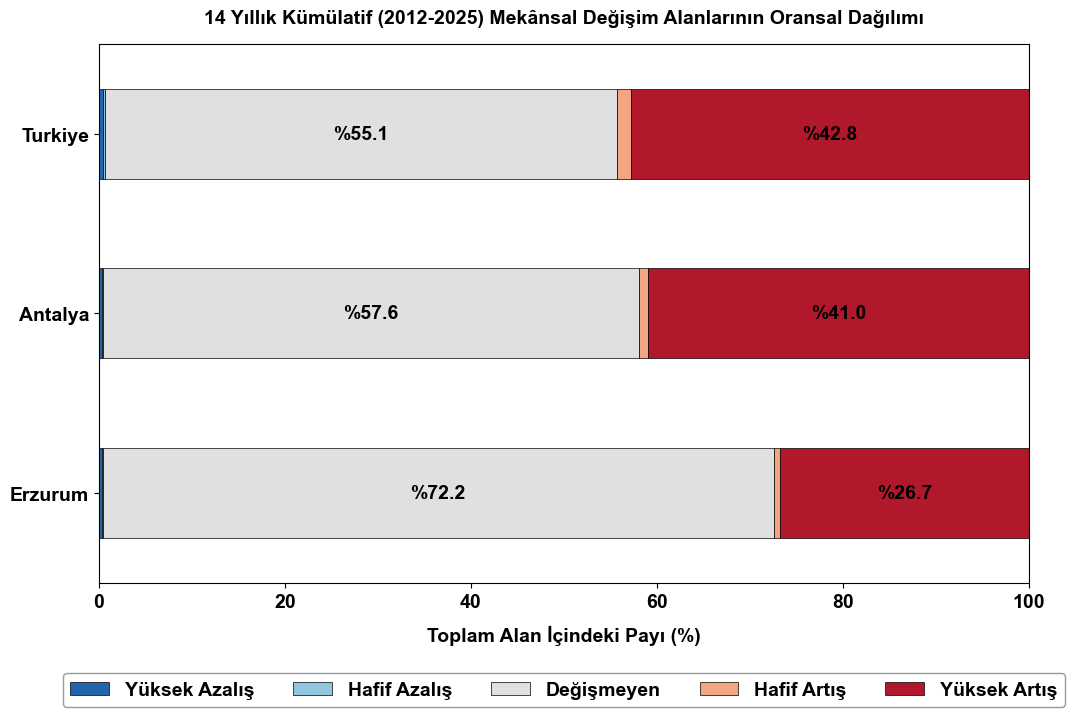


Kategorik Alan Dağılımı Grafiği Başarıyla Kaydedildi: SONUC_RAPORU_NTL_CDA_02_kategorik_alan_analizi.png


In [1]:

# Gerekli modülleri içe aktarıyoruz
import os
import glob
import rasterio
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import warnings
# Uyarı mesajlarını kapatıyoruz
warnings.filterwarnings('ignore')

# ==========================================
# GÖRSEL AYARLAR (rcParams)
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Helvetica', 'sans-serif']
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['font.size'] = 14              # Genel varsayılan yazı boyutu
plt.rcParams['font.weight'] = 'bold'         # Genel kalın yazı
plt.rcParams['axes.labelsize'] = 14          # Eksen etiketleri boyutu
plt.rcParams['axes.titlesize'] = 14          # Alt grafik başlıkları boyutu
plt.rcParams['xtick.labelsize'] = 14         # X koordinat tick boyutları
plt.rcParams['ytick.labelsize'] = 14         # Y koordinat tick boyutları
plt.rcParams['legend.fontsize'] = 14         # Lejant yazı boyutu
plt.rcParams['figure.titlesize'] = 16        # Ana figür başlığı boyutu

# ==========================================
# AYARLAR VE DİZİNLER
# ==========================================
# Fark haritalarının (TIFF) bulunduğu dizin yolu
cda_klasoru = r'C:\Users\HP\YandexDisk\ATASAM\=3501_2024\==notebooks\=cikti\cda'
# Analiz edilecek coğrafi bölgeler
bolgeler = ['Turkiye', 'Antalya', 'Erzurum']
# İncelenecek hedef zaman aralığı (14 yıllık toplam kümülatif değişim)
periyot = '2012-2025' # Analiz edilecek 14 yıllık toplam kümülatif periyot
katman_adi = 'NearNadir_Composite_Snow_Free' # Kullanılan en kararlı karsız katman

# ==========================================
# 1. SINIFLANDIRMA VE GERÇEK ALAN HESABI (Kosinüs Düzeltmeli)
# ==========================================
# Değişim matrisindeki delta (fark) değerlerini 5 anlamsal kategoriye ayırıyoruz
siniflar = {
    'Yüksek Azalış': {'sinir': lambda x: x < -0.5, 'renk': '#2166ac'},      # Koyu Mavi (Karartma/Tasarruf)
    'Hafif Azalış':  {'sinir': lambda x: (x >= -0.5) & (x < -0.1), 'renk': '#92c5de'}, # Açık Mavi
    'Değişmeyen': {'sinir': lambda x: (x >= -0.1) & (x <= 0.1), 'renk': '#e0e0e0'}, # Açık Gri (Karanlık/Doygun Alanlar)
    'Hafif Artış':   {'sinir': lambda x: (x > 0.1) & (x <= 0.5), 'renk': '#f4a582'},   # Açık Turuncu
    'Yüksek Artış':  {'sinir': lambda x: x > 0.5, 'renk': '#b2182b'}        # Koyu Kırmızı (Yoğun Kentsel Büyüme)
}

sonuclar_km2 = {s: [] for s in siniflar.keys()}
sonuclar_yuzde = {s: [] for s in siniflar.keys()}

print("="*80)
print("EŞİK DEĞER VE ALAN HESAPLAMA BAŞLADI")
print("-" * 80)

# Her bölge için sırasıyla fark haritalarını okuyup alan hesaplıyoruz
for bolge in bolgeler:
    # İlgili bölgeye ait FARK tiff dosyasını aratıyoruz
    dosya_kalibi = os.path.join(cda_klasoru, f"{bolge}_{katman_adi}_{periyot}_FARK.tif")
    bulunan_dosya = glob.glob(dosya_kalibi)
    
    if not bulunan_dosya:
        print(f"HATA: {bolge} için {periyot} periyoduna ait FARK dosyası bulunamadı!")
        for s in siniflar.keys():
            sonuclar_km2[s].append(0)
            sonuclar_yuzde[s].append(0)
        continue
        
    fark_dosyasi = bulunan_dosya[0]
    
    # Rasterio ile fark haritasını açıyoruz
    with rasterio.open(fark_dosyasi) as src:
        veri = src.read(1)
        nodata = src.nodata
        
        # ENLEME BAĞLI GERÇEK PİKSEL ALANI (km²), WGS84 coğrafi koordinat sisteminde boylam dereceleri enleme (cos(lat)) bağlı olarak kutuplara doğru daralır.
        yukseklik, genislik = veri.shape
        x_res = abs(src.transform[0]) # Piksel genişliği (derece cinsinden)
        y_res = abs(src.transform[4]) # Piksel yüksekliği (derece cinsinden)
        
        # Raster satır indekslerine karşılık gelen coğrafi enlem (latitude) dizisini türetiyoruz
        satir_indisleri = np.arange(yukseklik)
        enlemler = src.transform[5] + (satir_indisleri + 0.5) * src.transform[4]
        
        # Her satır için 2 boyutlu enlem matrisi oluşturuyoruz (Boylam boyunca enlem sabit kalır)
        enlem_matrisi = np.tile(enlemler[:, np.newaxis], (1, genislik))
        
        # 1 derece enlem ≈ 111.32 km, 1 derece boylam ≈ 111.32 * cos(enlem) km
        d_lat_km = y_res * 111.32
        d_lon_km = x_res * 111.32 * np.cos(np.radians(enlem_matrisi))
        
        # Raster üzerindeki her bir pikselin dünya üzerindeki gerçek alanını (km²) matris olarak hesaplıyoruz
        piksel_alan_matrisi = d_lat_km * d_lon_km
        
        # Nodata piksellerini (denizleri, sınır dışı boşlukları) haritalama dışı tutmak için maske oluşturuyoruz
        gecerli_maske = (veri != nodata) & (~np.isnan(veri))
        
        # Toplam karasal alan, geçerli piksellerin alan matrisindeki kümülatif toplamıdır
        toplam_alan_km2 = np.sum(piksel_alan_matrisi[gecerli_maske])
        
        print(f"\n--- {bolge.upper()} BÖLGESİ ---")
        print(f"Hesaplanan Gerçek Karasal Alan: {toplam_alan_km2:,.2f} km²")
        
        # Her bir değişim sınıfı için gerçek yüzey alanlarını ve oranlarını hesaplıyoruz
        for sinif_adi, ayarlar in siniflar.items():
            # İlgili sınıfın eşik koşulunu sağlayan ve karasal alan içinde kalan pikseller
            kosul = ayarlar['sinir'](veri) & gecerli_maske
            alan_km2 = np.sum(piksel_alan_matrisi[kosul])
            alan_yuzde = (alan_km2 / toplam_alan_km2) * 100.0
            
            sonuclar_km2[sinif_adi].append(alan_km2)
            sonuclar_yuzde[sinif_adi].append(alan_yuzde)
            
            print(f"  {sinif_adi}: {alan_km2:,.1f} km² (%{alan_yuzde:.2f})")

# Hesaplanan yüzdelik oranları Pandas DataFrame tablosuna aktarıyoruz
df_yuzde = pd.DataFrame(sonuclar_yuzde, index=bolgeler)

# ==========================================
# 2. YATAY YIĞILMIŞ ÇUBUK (STACKED BAR) ÇİZİMİ
# ==========================================
fig, ax = plt.subplots(figsize=(12, 7))
renk_listesi = [ayarlar['renk'] for ayarlar in siniflar.values()]

# Yatay yığılmış (stacked barh) çubuk grafiğini çizdiriyoruz
df_yuzde.plot(kind='barh', stacked=True, color=renk_listesi, ax=ax, edgecolor='black', linewidth=0.5)

# Barların içerisine okunabilir olması için yüzde etiketlerini yerleştiriyoruz
for n, (idx, row) in enumerate(df_yuzde.iterrows()):
    kümülatif_x = 0
    for val in row:
        # Sadece grafik üzerinde rahat sığacak ve kalabalık yapmayacak kadar büyük payları (%2 üstü) yazdırıyoruz
        if val > 2.0:  
            ax.text(kümülatif_x + val/2, n, f"%{val:.1f}", ha='center', va='center', color='black', weight='bold', fontsize=14)
        kümülatif_x += val

# Grafik başlığı ve eksen etiketlerinin Türkçe olarak ayarlanması
ax.set_title('14 Yıllık Kümülatif (2012-2025) Mekânsal Değişim Alanlarının Oransal Dağılımı', fontweight='bold', pad=15)
ax.set_xlabel('Toplam Alan İçindeki Payı (%)', fontweight='bold', labelpad=10)
ax.set_xlim([0, 100])
ax.invert_yaxis() # Türkiye en üstte, Erzurum en altta olacak şekilde sıralamayı ters çeviriyoruz

# Lejantın grafiğin altına yatay ve düzenli bir şekilde yerleştirilmesi
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, frameon=True, edgecolor='gray', facecolor='white')

# Çıktı dosya yolunu oluşturup grafiği yüksek çözünürlükte diske kaydediyoruz
cikti_yolu = os.path.join(cda_klasoru, 'SONUC_RAPORU_NTL_CDA_02_kategorik_alan_analizi.png')
plt.savefig(cikti_yolu, dpi=500, bbox_inches='tight')
plt.show()
plt.close()

print("\n" + "="*80)
print(f"Kategorik Alan Dağılımı Grafiği Başarıyla Kaydedildi: {os.path.basename(cikti_yolu)}")
print("="*80)



## **6.3 Katı Hal Aydınlatmasına Geçiş ve VIIRS Spektral Körlük (Kayıp Sinyal) Analizi**

- Uzaktan algılama ve ışık kirliliği çalışmalarında, uyduların sensör duyarlılık sınırları ile yeryüzündeki aydınlatma teknolojilerinin evrimi arasında kritik teknik ilişkiler bulunmaktadır. Özellikle 2017 sonrasında tüm dünyada ve ülkemizde sodyum buharlı (HPS - turuncu) lambalardan, enerji verimliliği yüksek beyaz LED (WLED - mavi ağırlıklı) teknolojisine geçiş süreci hızlanmıştır.

- Bu bölümde; Suomi-NPP VIIRS DNB sensörünün 500 nm altındaki dalga boylarına karşı kör olması (spektral duyarsızlığı) nedeniyle, kentsel alanlarda yapılaşma artmasına rağmen uydunun neden "karartma" (radyans azalışı) kaydettiğini inceleyeceğiz.

- 2017–2022 periyodunda, nüfus ve kentsel alan genişlemesine rağmen radyans değeri düşen pikselleri ($ΔNTL<−0.1$) "Yalancı Karartma / Mavi Körlük" maskesiyle izole ederek Türkiye, Antalya ve Erzurum genelindeki alansal karşılıklarını ($km^2$ ve $\%$) hesaplayıp bu spektral kaybı sayısal olarak ortaya koyacağız.


LED GEÇİŞİ VE 'MAVİ KÖRLÜK' (KAYIP SİNYAL) TESPİT ANALİZİ
--------------------------------------------------------------------------------

 BÖLGE: TURKIYE (Dönem: 2017-2022)
SONUC_RAPORU: Toplam Karasal Alan           : 781,806.34 km²
SONUC_RAPORU: Yalancı Karartma (Mavi Körlük) Alanı : 15,894.64 km²
SONUC_RAPORU: Toplam Karasal Alan İçindeki Payı  : %2.0331

 BÖLGE: ANTALYA (Dönem: 2017-2022)
SONUC_RAPORU: Toplam Karasal Alan           : 21,206.68 km²
SONUC_RAPORU: Yalancı Karartma (Mavi Körlük) Alanı : 329.74 km²
SONUC_RAPORU: Toplam Karasal Alan İçindeki Payı  : %1.5549

 BÖLGE: ERZURUM (Dönem: 2017-2022)
SONUC_RAPORU: Toplam Karasal Alan           : 24,376.83 km²
SONUC_RAPORU: Yalancı Karartma (Mavi Körlük) Alanı : 287.13 km²
SONUC_RAPORU: Toplam Karasal Alan İçindeki Payı  : %1.1779

Mavi Körlük ve Spektral Kayıp Sinyal Analizi Başarıyla Tamamlandı.


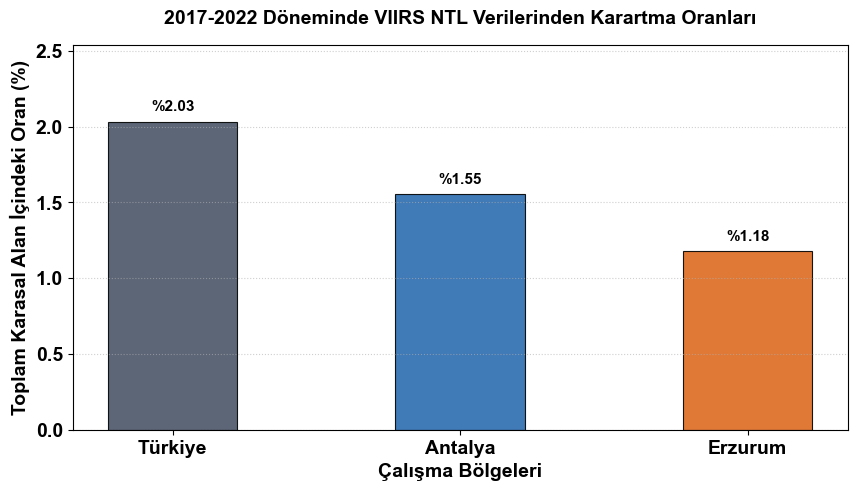

SONUC_RAPORU: ================================================================================
SONUC_RAPORU: Mavi Körlük Karşılaştırma Grafiği Başarıyla Kaydedildi : C:\Users\HP\YandexDisk\ATASAM\=3501_2024\==notebooks\=cikti\cda\SONUC_RAPORU_NTL_CDA_03_mavi_korluk_karsilastirma.png
SONUC_RAPORU: ================================================================================


In [1]:

# Gerekli modülleri içe aktarıyoruz
import os
import glob
import rasterio
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import warnings
# Uyarı mesajlarını kapatıyoruz
warnings.filterwarnings('ignore')

# ==========================================
# AYARLAR VE DİZİNLER
# ==========================================
# Değişim tespiti (CDA) TIFF dosyalarının bulunduğu klasör yolu
cda_klasoru = r'C:\Users\HP\YandexDisk\ATASAM\=3501_2024\==notebooks\=cikti\cda'
# İncelemek istediğimiz periyot: LED dönüşümünün ve mavi körlüğün yoğun olduğu dönem
periyot = '2017-2022'
# Kullanılacak en kararlı karsız katman
katman_adi = 'NearNadir_Composite_Snow_Free'

# Analiz edilecek hedef bölgeler listesi
bolgeler = ['Turkiye', 'Antalya', 'Erzurum']

# Görselleştirme için sonuçları saklayacağımız liste yapıları
islenen_bolgeler = []
karartma_yuzdeleri = []

print("="*80)
print("LED GEÇİŞİ VE 'MAVİ KÖRLÜK' (KAYIP SİNYAL) TESPİT ANALİZİ")
print("-" * 80)

# Her bir bölge için sırasıyla döngü başlatıyoruz
for bolge in bolgeler:
    # İlgili bölgeye ve periyoda ait FARK haritasının dosya yolunu oluşturuyoruz
    dosya_kalibi = os.path.join(cda_klasoru, f"{bolge}_{katman_adi}_{periyot}_FARK.tif")
    bulunan_dosya = glob.glob(dosya_kalibi)
    
    # Dosya bulunamazsa uyarı verip sonraki bölgeye geçiyoruz
    if not bulunan_dosya:
        print(f"SONUC_RAPORU: UYARI - {bolge} için {periyot} periyoduna ait FARK dosyası bulunamadı!")
        continue
        
    fark_dosyasi = bulunan_dosya[0]
    
    # rasterio kütüphanesi ile fark haritası raster dosyasını açıyoruz
    with rasterio.open(fark_dosyasi) as src:
        # Piksel matrisini ondalık (float) sayı tipinde okuyoruz
        veri = src.read(1).astype(float)
        nodata = src.nodata
        
        # Enleme ve boylama bağlı piksel alanı hesablanıyor
        yukseklik, genislik = veri.shape
        x_res = abs(src.transform[0]) 
        y_res = abs(src.transform[4]) 
        
        satir_indisleri = np.arange(yukseklik)
        enlemler = src.transform[5] + (satir_indisleri + 0.5) * src.transform[4]
        enlem_matrisi = np.tile(enlemler[:, np.newaxis], (1, genislik))
        
        d_lat_km = y_res * 111.32
        d_lon_km = x_res * 111.32 * np.cos(np.radians(enlem_matrisi))
        piksel_alan_matrisi = d_lat_km * d_lon_km
        
        # Geçerli karasal pikseller maskesi (Nodatalar ve NaN değerler hariç tutulur)
        if nodata is not None:
            gecerli_maske = (veri != nodata) & (~np.isnan(veri))
        else:
            gecerli_maske = ~np.isnan(veri)
        
        # Toplam karasal alanın km² cinsinden kümülatif toplamı
        toplam_karasal_alan = np.sum(piksel_alan_matrisi[gecerli_maske])
        
        # MAVİ KÖRLÜK / YALANCI KARARTMA MASKESİ: Nüfus ve yapılaşma artmasına rağmen spektral körlük nedeniyle radyansı düşen (Delta NTL < -0.1) pikseller seçilir.
        karartma_maskesi = (veri < -0.1) & gecerli_maske
        
        # Yalancı karartma alanının km² ve yüzde cinsinden karşılığı hesaplanır
        karartma_alan_km2 = np.sum(piksel_alan_matrisi[karartma_maskesi])
        karartma_yuzde = (karartma_alan_km2 / toplam_karasal_alan) * 100.0 if toplam_karasal_alan > 0 else 0
        
        # Grafik için bölge adını ve hesaplanan yüzdeyi listelere ekliyoruz
        islenen_bolgeler.append('Türkiye' if bolge == 'Turkiye' else bolge)
        karartma_yuzdeleri.append(karartma_yuzde)
        
        # Konsol Sonuç Raporlaması
        print(f"\n{'='*50}\n BÖLGE: {bolge.upper()} (Dönem: {periyot})\n{'='*50}")
        print(f"SONUC_RAPORU: Toplam Karasal Alan           : {toplam_karasal_alan:,.2f} km²")
        print(f"SONUC_RAPORU: Yalancı Karartma (Mavi Körlük) Alanı : {karartma_alan_km2:,.2f} km²")
        print(f"SONUC_RAPORU: Toplam Karasal Alan İçindeki Payı  : %{karartma_yuzde:.4f}")
        print("="*80)

print("\nMavi Körlük ve Spektral Kayıp Sinyal Analizi Başarıyla Tamamlandı.")

# ==========================================
# GÖRSELLEŞTİRME (Sütun Grafik - Bar Chart)
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Helvetica', 'sans-serif']
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['font.size'] = 14              # Genel varsayılan yazı boyutu
plt.rcParams['font.weight'] = 'bold'         # Genel kalın yazı
plt.rcParams['axes.labelsize'] = 14          # Eksen etiketleri boyutu
plt.rcParams['axes.titlesize'] = 14          # Alt grafik başlıkları boyutu
plt.rcParams['xtick.labelsize'] = 14         # X koordinat tick boyutları
plt.rcParams['ytick.labelsize'] = 14         # Y koordinat tick boyutları
plt.rcParams['legend.fontsize'] = 14         # Lejant yazı boyutu
plt.rcParams['figure.titlesize'] = 16        # Ana figür başlığı boyutu

fig, ax = plt.subplots(figsize=(10, 5))
# Bölgeleri temsil edecek renk paleti (Gri, Mavi, Turuncu)
renkler = ['#4a5568', '#2b6cb0', '#dd6b20']

# Sütun (bar) grafiğinin çizilmesi
birlikler = ax.bar(islenen_bolgeler, karartma_yuzdeleri, color=renkler[:len(islenen_bolgeler)], width=0.45, edgecolor='black', linewidth=0.8, alpha=0.9)

# Her bir sütünün üzerine hesaplanan yüzde değerlerinin ortalanarak yazdırılması
for bar in birlikler:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.05, f"%{yval:.2f}", ha='center', va='bottom', fontweight='bold', fontsize=11)

# Grafik başlığı, eksen etiketleri ve ızgara (grid) çizgilerinin eklenmesi
ax.set_title('2017-2022 Döneminde VIIRS NTL Verilerinden Karartma Oranları', fontweight='bold', pad=15)
ax.set_ylabel('Toplam Karasal Alan İçindeki Oran (%)', fontweight='bold')
ax.set_xlabel('Çalışma Bölgeleri', fontweight='bold')
ax.set_ylim([0, max(karartma_yuzdeleri) * 1.25 if karartma_yuzdeleri else 2.5])
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Çıktı klasörünün sistemde var olup olmadığının kontrolü, yoksa oluşturulması
cikti_klasoru_sekil = os.path.join(os.path.dirname(cda_klasoru), 'cda')
if not os.path.exists(cikti_klasoru_sekil):
    os.makedirs(cikti_klasoru_sekil)

# Üretilen grafiğin yüksek çözünürlükte diske kaydedilmesi
cikti_yolu = os.path.join(cikti_klasoru_sekil, 'SONUC_RAPORU_NTL_CDA_03_mavi_korluk_karsilastirma.png')
plt.savefig(cikti_yolu, dpi=500, bbox_inches='tight')
plt.show()
plt.close()

print('SONUC_RAPORU: ' + '='*80)
print(f"SONUC_RAPORU: Mavi Körlük Karşılaştırma Grafiği Başarıyla Kaydedildi : {cikti_yolu}")
print('SONUC_RAPORU: ' + '='*80)



## **6.4 Kentsel Büyüme Vektörleri ve Yönsel Sızıntı Analizi**

- Önceki adımlarda ürettiğimiz mekânsal değişim haritaları, kentsel aydınlanmanın ülke genelinde ve iller bazında arttığını görsel olarak kanıtlamıştır. Ancak bu aydınlanma artışının gözlemevlerinin (TUG ve DAG) hangi coğrafi yönlerinde ve hangi mesafe bantlarında yoğunlaştığını matematiksel olarak bilmek, koruma bandı planlamaları açısından kritik bir gerekliliktir.

- Bu bölümde; 14 yıllık kümülatif değişim haritalarındaki yüksek aydınlanma artış piksellerini ($ΔNTL>0.5$) mercek altına alarak bir yönsel vektör ve mesafesel dağılım analizi gerçekleştireceğiz.

- Gözlemevlerinin coğrafi konumlarını merkez ($0$ km) kabul eden algoritma; her bir artış pikselinin gözlemevine olan kuş uçuşu mesafesini ($0−10$ km, $10−25$ km, $25−50$ km ve $50+$ km) ve pusula yönünü (Kuzey, Kuzeydoğu, Doğu vb.) 2 boyutlu matrisler üzerinde hesaplamaktadır. Bu sayede, kentsel kirlilik baskısının gözlemevlerine hangi eksenlerden yaklaştığını istatistiksel metriklerle raporlayabileceğiz.

- Aşağıdaki Python kodu; TUG ve DAG gözlemevleri için hem mesafesel kümelenme yüzdelerini hesaplamakta hem de 8 ana pusula yönüne göre dağılımı gösteren 2x2 formatındaki bütünleşik görseli (sol sütunda çubuk grafikler, sağ sütunda kutupsal diyagramlar) otomatik olarak üretmektedir.


MEKÂNSAL BÜYÜME VE YÖNSEL VEKTÖR ANALİZİ BAŞLADI
--------------------------------------------------------------------------------

 GÖZLEMEVİ: TUG (Antalya)
Toplam Yüksek Artış Piksel Sayısı: 50,445

Mekânsal Dağılım (Gözlemevine Uzaklık):
  - 0 ila 10 km arası  : %1.13
  - 10 ila 25 km arası : %5.94
  - 25 ila 50 km arası : %28.46
  - 50 km ve ötesi     : %64.48

Yönsel Dağılım (Kentsel Işık Artışının Yoğunlaştığı Doğrultu):
  - Kuzey          : %6.90
  - KuzeyDoğu      : %15.72
  - Doğu           : %44.04
  - Güneydoğu      : %2.19
  - Güney          : %7.63
  - Güneybatı      : %14.69
  - Batı           : %5.12
  - Kuzeybatı      : %3.72

=> SONUÇ: TUG için en yoğun kentsel ışık artış vektörü '%44.04' oranında [Doğu] yönünde gerçekleşmiştir.

 GÖZLEMEVİ: DAG (Erzurum)
Toplam Yüksek Artış Piksel Sayısı: 39,544

Mekânsal Dağılım (Gözlemevine Uzaklık):
  - 0 ila 10 km arası  : %3.15
  - 10 ila 25 km arası : %12.08
  - 25 ila 50 km arası : %25.51
  - 50 km ve ötesi     : %59.27

Yönsel 

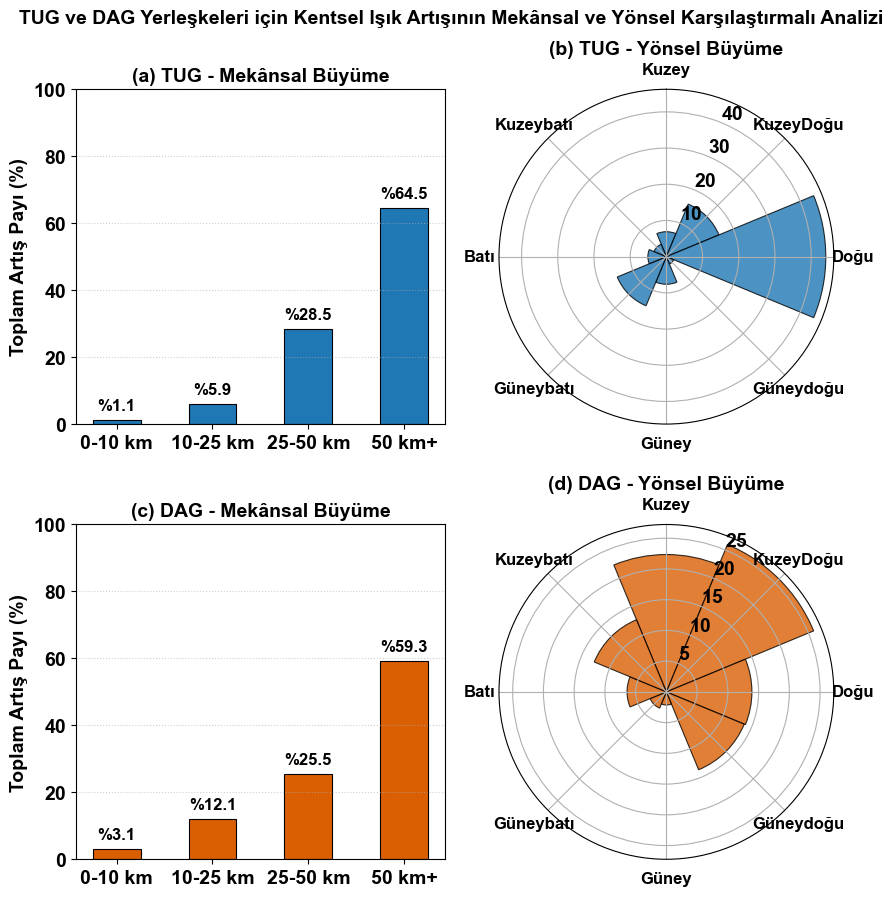


TUG ve DAG Analiz Görseli Başarıyla Kaydedildi: SONUC_RAPORU_NTL_CDA_04_TUG_DAG_mekansal_analiz.png


In [1]:

# Gerekli modülleri içe aktarıyoruz
import os
import glob
import rasterio
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import warnings
# Uyarı mesajlarını kapatıyoruz
warnings.filterwarnings('ignore')

# ==========================================
# GÖRSEL AYARLAR (rcParams)
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Helvetica', 'sans-serif']
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['font.size'] = 14              # Genel varsayılan yazı boyutu
plt.rcParams['font.weight'] = 'bold'         # Genel kalın yazı
plt.rcParams['axes.labelsize'] = 14          # Eksen etiketleri boyutu
plt.rcParams['axes.titlesize'] = 14          # Alt grafik başlıkları boyutu
plt.rcParams['xtick.labelsize'] = 14         # X koordinat tick boyutları
plt.rcParams['ytick.labelsize'] = 14         # Y koordinat tick boyutları
plt.rcParams['legend.fontsize'] = 14         # Lejant yazı boyutu
plt.rcParams['figure.titlesize'] = 16        # Ana figür başlığı boyutu

# ==========================================
# AYARLAR VE DİZİNLER
# ==========================================
cda_klasoru = r'C:\Users\HP\YandexDisk\ATASAM\=3501_2024\==notebooks\=cikti\cda'
periyot = '2012-2025' # 14 yıllık toplam kümülatif değişim
katman_adi = 'NearNadir_Composite_Snow_Free' # Kullanılan en kararlı karsız katman

# Gözlemevlerinin WGS84 coğrafi koordinatları ve renkleri TUG: Mavi tonu, DAG: Turuncu tonu
gozlemevleri = {
    'Antalya': {'isim': 'TUG', 'lon': 30.335452, 'lat': 36.824152, 'renk': '#1f77b4'},
    'Erzurum': {'isim': 'DAG', 'lon': 41.226402, 'lat': 39.780420, 'renk': '#d95f02'}
}

print("="*80)
print("MEKÂNSAL BÜYÜME VE YÖNSEL VEKTÖR ANALİZİ BAŞLADI")
print("-" * 80)

# 2x2 Matris figürünü oluşturuyoruz (Satır 0: TUG, Satır 1: DAG), Sütun 0: Mekânsal Dağılım (Bar), Sütun 1: Yönsel Dağılım (Polar Rose Diagram)
fig = plt.figure(figsize=(10, 10))

ax_tug_bar = fig.add_subplot(2, 2, 1)
ax_tug_polar = fig.add_subplot(2, 2, 2, projection='polar')

ax_dag_bar = fig.add_subplot(2, 2, 3)
ax_dag_polar = fig.add_subplot(2, 2, 4, projection='polar')

panel_eslesmeleri = [
    ('Antalya', ax_tug_bar, ax_tug_polar),
    ('Erzurum', ax_dag_bar, ax_dag_polar)
]

# Döngü öncesinde satır indeksini sıfırdan başlatıyoruz
row_idx = 0

for bolge_adi, ax_bar, ax_polar in panel_eslesmeleri:
    obs = gozlemevleri[bolge_adi]
    dosya_kalibi = os.path.join(cda_klasoru, f"{bolge_adi}_{katman_adi}_{periyot}_FARK.tif")
    bulunan_dosya = glob.glob(dosya_kalibi)
    
    if not bulunan_dosya:
        print(f"HATA: {bolge_adi} için {periyot} periyoduna ait FARK dosyası bulunamadı!")
        row_idx += 1
        continue
        
    fark_dosyasi = bulunan_dosya[0]
    
    with rasterio.open(fark_dosyasi) as src:
        veri = src.read(1).astype(float)
        nodata = src.nodata
        
        yukseklik, genislik = veri.shape
        
        # 2 Boyutlu Enlem ve Boylam Matrislerinin Oluşturulması
        sol_ust_x = src.transform[2]
        sol_ust_y = src.transform[5]
        x_cozunurluk = src.transform[0]
        y_cozunurluk = src.transform[4]
        
        boylamlar = sol_ust_x + (np.arange(genislik) + 0.5) * x_cozunurluk
        enlemler = sol_ust_y + (np.arange(yukseklik) + 0.5) * y_cozunurluk
        lon_matrisi, lat_matrisi = np.meshgrid(boylamlar, enlemler)
        
        obs_lon, obs_lat = obs['lon'], obs['lat']
        
        # Kuş uçuşu mesafe ve yön açısı matrisleri
        d_lat_km = (lat_matrisi - obs_lat) * 111.32
        d_lon_km = (lon_matrisi - obs_lon) * 111.32 * np.cos(np.radians(obs_lat))
        mesafe_matrisi = np.sqrt(d_lat_km**2 + d_lon_km**2)
        
        aci_radyan = np.arctan2(d_lon_km, d_lat_km) 
        aci_derece = np.degrees(aci_radyan) % 360
        
        # Geçerli karasal piksel maskeleme
        if nodata is not None:
            gecerli_maske = (veri != nodata) & (~np.isnan(veri))
        else:
            gecerli_maske = ~np.isnan(veri)
            
        artis_maskesi = (veri > 0.5) & gecerli_maske
        
        artis_mesafeleri = mesafe_matrisi[artis_maskesi]
        artis_aciklari = aci_derece[artis_maskesi]
        toplam_artis_pikseli = len(artis_mesafeleri)
        
        # Mekânsal hesaplar
        halka_0_10 = np.sum(artis_mesafeleri <= 10)
        halka_10_25 = np.sum((artis_mesafeleri > 10) & (artis_mesafeleri <= 25))
        halka_25_50 = np.sum((artis_mesafeleri > 25) & (artis_mesafeleri <= 50))
        halka_50_plus = np.sum(artis_mesafeleri > 50)
        
        if toplam_artis_pikseli > 0:
            yuzde_0_10 = (halka_0_10 / toplam_artis_pikseli) * 100
            yuzde_10_25 = (halka_10_25 / toplam_artis_pikseli) * 100
            yuzde_25_50 = (halka_25_50 / toplam_artis_pikseli) * 100
            yuzde_50_plus = (halka_50_plus / toplam_artis_pikseli) * 100
        else:
            yuzde_0_10 = yuzde_10_25 = yuzde_25_50 = yuzde_50_plus = 0.0
            
        # Yönsel hesaplar (8 Ana Yön)
        yon_isimleri = ['Kuzey', 'KuzeyDoğu', 'Doğu', 'Güneydoğu', 
                        'Güney', 'Güneybatı', 'Batı', 'Kuzeybatı']
        
        yon_kosullari = [
            ((artis_aciklari >= 337.5) | (artis_aciklari < 22.5)),
            ((artis_aciklari >= 22.5) & (artis_aciklari < 67.5)),
            ((artis_aciklari >= 67.5) & (artis_aciklari < 112.5)),
            ((artis_aciklari >= 112.5) & (artis_aciklari < 157.5)),
            ((artis_aciklari >= 157.5) & (artis_aciklari < 202.5)),
            ((artis_aciklari >= 202.5) & (artis_aciklari < 247.5)),
            ((artis_aciklari >= 247.5) & (artis_aciklari < 292.5)),
            ((artis_aciklari >= 292.5) & (artis_aciklari < 337.5))
        ]
        
        yon_oranlari = []
        en_yogun_yon = ""
        en_yuksek_oran = 0
        
        for adi, kosul in zip(yon_isimleri, yon_kosullari):
            adet = np.sum(kosul)
            oran = (adet / toplam_artis_pikseli) * 100 if toplam_artis_pikseli > 0 else 0
            yon_oranlari.append(oran)
            if oran > en_yuksek_oran:
                en_yuksek_oran = oran
                en_yogun_yon = adi

        # Konsol Çıktısı
        print(f"\n{'='*40}\n GÖZLEMEVİ: {obs['isim']} ({bolge_adi})\n{'='*40}")
        print(f"Toplam Yüksek Artış Piksel Sayısı: {toplam_artis_pikseli:,}")
        print("\nMekânsal Dağılım (Gözlemevine Uzaklık):")
        print(f"  - 0 ila 10 km arası  : %{yuzde_0_10:.2f}")
        print(f"  - 10 ila 25 km arası : %{yuzde_10_25:.2f}")
        print(f"  - 25 ila 50 km arası : %{yuzde_25_50:.2f}")
        print(f"  - 50 km ve ötesi     : %{yuzde_50_plus:.2f}")
        
        print("\nYönsel Dağılım (Kentsel Işık Artışının Yoğunlaştığı Doğrultu):")
        for yon_adi, oran in zip(yon_isimleri, yon_oranlari):
            print(f"  - {yon_adi:15}: %{oran:.2f}")
            
        print(f"\n=> SONUÇ: {obs['isim']} için en yoğun kentsel ışık artış vektörü '%{en_yuksek_oran:.2f}' oranında [{en_yogun_yon}] yönünde gerçekleşmiştir.")
        print("="*80)

        # Sol Sütun - Mekânsal Dağılım (Bar Chart)
        mesafe_etiketleri = ['0-10 km', '10-25 km', '25-50 km', '50 km+']
        mesafe_degerleri = [yuzde_0_10, yuzde_10_25, yuzde_25_50, yuzde_50_plus]
        
        ax_bar.bar(mesafe_etiketleri, mesafe_degerleri, color=obs['renk'], width=0.5, edgecolor='black', linewidth=0.8)
        ax_bar.set_title(f'({chr(97 + row_idx*2)}) {obs["isim"]} - Mekânsal Büyüme', fontweight='bold')
        ax_bar.set_ylabel('Toplam Artış Payı (%)', fontweight='bold')
        ax_bar.set_ylim([0, 100])
        ax_bar.grid(axis='y', linestyle=':', alpha=0.6)
        
        for i, v in enumerate(mesafe_degerleri):
            ax_bar.text(i, v + 2, f"%{v:.1f}", ha='center', va='bottom', fontweight='bold', fontsize=12)

        # Sağ Sütun - Yönsel Dağılım (Polar Rose Diagram)
        aci_radyanlari = np.deg2rad(np.linspace(0, 360, len(yon_isimleri), endpoint=False))
        genislik = np.deg2rad(45)
        
        ax_polar.bar(aci_radyanlari, yon_oranlari, width=genislik, bottom=0.0, color=obs['renk'], alpha=0.8, edgecolor='black', linewidth=0.8)
        
        ax_polar.set_theta_zero_location('N')
        ax_polar.set_theta_direction(-1)
        ax_polar.set_xticks(aci_radyanlari)
        ax_polar.set_xticklabels(yon_isimleri, fontweight='bold', fontsize=12)
        ax_polar.set_title(f'({chr(98 + row_idx*2)}) {obs["isim"]} - Yönsel Büyüme', fontweight='bold') #, pad=15)

    row_idx += 1

# Genel Başlık ve Düzen
plt.subplots_adjust(wspace=0.1, hspace=0.3)
fig.suptitle('TUG ve DAG Yerleşkeleri için Kentsel Işık Artışının Mekânsal ve Yönsel Karşılaştırmalı Analizi', fontweight='bold', y=0.96, fontsize=14)

# Kaydetme
cikti_klasoru = '=cikti/cda'
if not os.path.exists(cikti_klasoru):
    os.makedirs(cikti_klasoru)

cikti_yolu = os.path.join(cikti_klasoru, "SONUC_RAPORU_NTL_CDA_04_TUG_DAG_mekansal_analiz.png")
plt.savefig(cikti_yolu, dpi=500, bbox_inches='tight')
plt.show()
plt.close()

print("\n" + "="*80)
print(f"TUG ve DAG Analiz Görseli Başarıyla Kaydedildi: {os.path.basename(cikti_yolu)}")
print("="*80)



## **6.5 Kırsal Alan ve Karanlık Gökyüzü Kayıp Analizi**

- Gözlemevleri için çevresel tehditleri değerlendirirken odaklanılması gereken en kritik konulardan biri, şehir merkezlerinin ne kadar parladığından ziyade, gözlemevini çevreleyen ve bugüne kadar zifiri karanlık olarak kalmış olan doğal sığınakların zaman içinde yapay ışık sızıntısına maruz kalıp kalmadığıdır.

- Bu bölümde; 2012 yılında tamamen karanlık nitelikte olan ($NTL≤0.3 nW/cm^2/sr$)  kırsal ve dağlık piksellerin, 2025 yılına gelindiğinde aydınlanarak ($NTL>0.8 nW/cm^2/sr$) karanlık vasfını yitirme oranını ($km^2$ ve $\%$) hesaplayacağız.

- Aşağıdaki Python kodu; 2012 ve 2025 yıllarına ait karsız yüzey arazilerini enleme bağlı kosinüs düzeltmeli gerçek piksel alan matrisleri üzerinden çakıştıracak, doğal karanlık alanların kentsel yayılma nedeniyle hangi oranda eridiğini ve aktif aydınlanma havzasına dahil olduğunu hem sayısal metriklerle raporlayacak hem de yıllar bazındaki kümülatif kayıp trendini sütun grafikleriyle görselleştirecektir.


KARANLIK ALAN (DARK SKY) KAYIP ANALİZİ BAŞLADI
--------------------------------------------------------------------------------

 BÖLGE: TURKIYE (Referans Yıl: 2012)
SONUC_RAPORU: Toplam Karasal Alan                  : 781,804.03 km²
SONUC_RAPORU: 2012 Yılı Başlangıç Karanlık Alanı   : 662,168.00 km²
SONUC_RAPORU: Yıl 2013 -> Kayıp Alan: 954.3 km² (Başlangıç Karanlığına Oranı: %0.14)
SONUC_RAPORU: Yıl 2014 -> Kayıp Alan: 1,513.5 km² (Başlangıç Karanlığına Oranı: %0.23)
SONUC_RAPORU: Yıl 2015 -> Kayıp Alan: 2,896.9 km² (Başlangıç Karanlığına Oranı: %0.44)
SONUC_RAPORU: Yıl 2016 -> Kayıp Alan: 4,279.2 km² (Başlangıç Karanlığına Oranı: %0.65)
SONUC_RAPORU: Yıl 2017 -> Kayıp Alan: 6,793.7 km² (Başlangıç Karanlığına Oranı: %1.03)
SONUC_RAPORU: Yıl 2018 -> Kayıp Alan: 9,604.8 km² (Başlangıç Karanlığına Oranı: %1.45)
SONUC_RAPORU: Yıl 2019 -> Kayıp Alan: 12,906.2 km² (Başlangıç Karanlığına Oranı: %1.95)
SONUC_RAPORU: Yıl 2020 -> Kayıp Alan: 13,975.2 km² (Başlangıç Karanlığına Oranı: %2.11)
SO

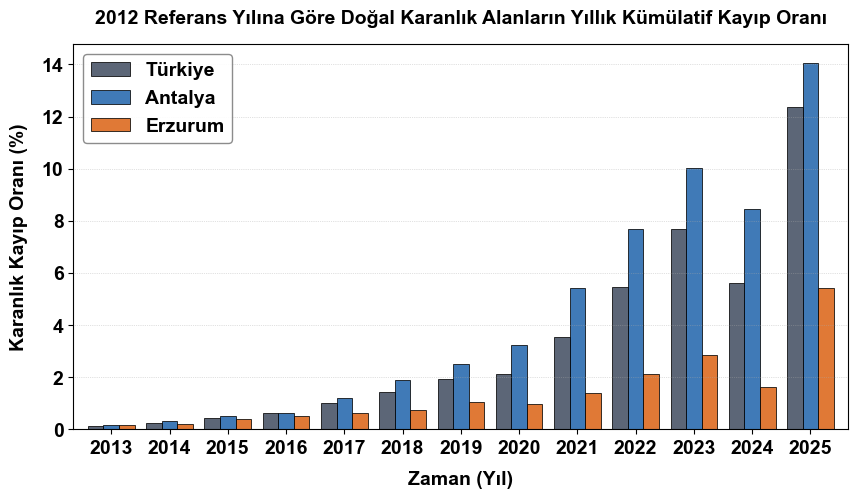


Sütun Grafiği Başarıyla Kaydedildi: SONUC_RAPORU_NTL_CDA_05_yillik_karanlik_kayip_trendi.png


In [1]:

# Gerekli modülleri içe aktarıyoruz
import os
import glob
import rasterio
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import warnings
# Uyarı mesajlarını kapatıyoruz
warnings.filterwarnings('ignore')

# ==========================================
# GÖRSEL AYARLAR (rcParams)
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Helvetica', 'sans-serif']
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['font.size'] = 14              # Genel varsayılan yazı boyutu
plt.rcParams['font.weight'] = 'bold'         # Genel kalın yazı
plt.rcParams['axes.labelsize'] = 14          # Eksen etiketleri boyutu
plt.rcParams['axes.titlesize'] = 14          # Alt grafik başlıkları boyutu
plt.rcParams['xtick.labelsize'] = 14         # X koordinat tick boyutları
plt.rcParams['ytick.labelsize'] = 14         # Y koordinat tick boyutları
plt.rcParams['legend.fontsize'] = 14         # Lejant yazı boyutu
plt.rcParams['figure.titlesize'] = 16        # Ana figür başlığı boyutu

# ==========================================
# AYARLAR VE DİZİNLER
# ==========================================
# Maskelenmiş karsız yıllık NTL GeoTIFF dosyalarının bulunduğu kaynak klasör
kaynak_klasor = r'E:\=PROJELER\=TUBITAK_3501_2024\veri\uydu\viirs_ntl\TifFiles\VNP46A4'
katman_adi = 'NearNadir_Composite_Snow_Free'

# Analiz edilecek hedef bölgeler
bolgeler = ['Turkiye', 'Antalya', 'Erzurum']

# Sabit referans yıl (2012) ve kıyaslanacak hedef yıllar dizisi
ref_yil = 2012
hedef_yillar = list(range(2013, 2026)) # 2013'ten 2025'e kadar tüm yıllar

print("="*80)
print("KARANLIK ALAN (DARK SKY) KAYIP ANALİZİ BAŞLADI")
print("-" * 80)

# Tüm bölgelerin yıllık kayıp yüzdelerini saklamak için sözlük yapısı
yillik_kayip_sozlugu = {b: [] for b in bolgeler}
yillik_kayip_km2 = {b: [] for b in bolgeler}

for bolge in bolgeler:
    dosya_2012_ara = glob.glob(os.path.join(kaynak_klasor, f"VNP46A4.A{ref_yil}001*{katman_adi}*.{bolge}.tif"))
    
    if not dosya_2012_ara:
        print(f"HATA: {bolge} için referans yıl ({ref_yil}) dosyası bulunamadı!")
        continue
        
    with rasterio.open(dosya_2012_ara[0]) as src12:
        v12 = src12.read(1).astype(float)
        nodata = src12.nodata
        
        # Enleme bağlı piksel alanı hesaplama
        yukseklik, genislik = v12.shape
        x_res = abs(src12.transform[0])
        y_res = abs(src12.transform[4])
        
        satir_indisleri = np.arange(yukseklik)
        enlemler = src12.transform[5] + (satir_indisleri + 0.5) * src12.transform[4]
        enlem_matrisi = np.tile(enlemler[:, np.newaxis], (1, genislik))
        
        d_lat_km = y_res * 111.32
        d_lon_km = x_res * 111.32 * np.cos(np.radians(enlem_matrisi))
        piksel_alan_matrisi = d_lat_km * d_lon_km
        
        # Karasal geçerli pikseller maskesi
        if nodata is not None:
            gecerli_maske_12 = (v12 != nodata) & (~np.isnan(v12))
        else:
            gecerli_maske_12 = (~np.isnan(v12))
            
        toplam_karasal_alan = np.sum(piksel_alan_matrisi[gecerli_maske_12])
        
        # Referans yılda (2012) tamamen karanlık olan pikseller (Örn: NTL <= 0.3)
        karanlik_2012 = (v12 <= 0.3) & gecerli_maske_12
        toplam_karanlik_alan_2012 = np.sum(piksel_alan_matrisi[karanlik_2012])
        
        print(f"\n{'='*50}\n BÖLGE: {bolge.upper()} (Referans Yıl: {ref_yil})\n{'='*50}")
        print(f"SONUC_RAPORU: Toplam Karasal Alan                  : {toplam_karasal_alan:,.2f} km²")
        print(f"SONUC_RAPORU: 2012 Yılı Başlangıç Karanlık Alanı   : {toplam_karanlik_alan_2012:,.2f} km²")
        
        # Her bir hedef yıl için 2012'ye kıyasla kayıp analizi
        for yil in hedef_yillar:
            dosya_hedef_ara = glob.glob(os.path.join(kaynak_klasor, f"VNP46A4.A{yil}001*{katman_adi}*.{bolge}.tif"))
            
            if not dosya_hedef_ara:
                yillik_kayip_sozlugu[bolge].append(np.nan)
                yillik_kayip_km2[bolge].append(np.nan)
                continue
                
            with rasterio.open(dosya_hedef_ara[0]) as srch:
                vh = srch.read(1).astype(float)
                vh[vh == srch.nodata] = np.nan
                
                # 2012'de karanlık olup, hedef yılda aydınlanan pikseller -> Kayıp Sığınaklar
                kayip_maskesi = karanlik_2012 & (vh > 0.8) & (~np.isnan(vh))
                
                kayip_alan_km2 = np.sum(piksel_alan_matrisi[kayip_maskesi])
                kayip_orani = (kayip_alan_km2 / toplam_karanlik_alan_2012) * 100.0 if toplam_karanlik_alan_2012 > 0 else 0.0
                
                yillik_kayip_sozlugu[bolge].append(kayip_orani)
                yillik_kayip_km2[bolge].append(kayip_alan_km2)
                
                print(f"SONUC_RAPORU: Yıl {yil} -> Kayıp Alan: {kayip_alan_km2:,.1f} km² (Başlangıç Karanlığına Oranı: %{kayip_orani:.2f})")
        print("="*80)

# Verileri pandas DataFrame yapısına dönüştürüyoruz
df_trend_km2 = pd.DataFrame(yillik_kayip_km2, index=hedef_yillar)
df_trend_yuzde = pd.DataFrame(yillik_kayip_sozlugu, index=hedef_yillar)

# ==========================================
# GÖRSELLEŞTİRME (Gruplandırılmış Sütun Grafik)
# ==========================================
fig, ax = plt.subplots(figsize=(10, 5))

# Sütun renkleri ve Türkçe etiket eşleştirmeleri
renkler = ['#4a5568', '#2b6cb0', '#dd6b20'] # Türkiye, Antalya, Erzurum
sutun_etiketleri = ['Türkiye', 'Antalya', 'Erzurum']

# DataFrame kolon isimlerini grafik lejantı için güncelliyoruz
df_trend_yuzde.columns = sutun_etiketleri

# Pandas plot ile gruplandırılmış sütun (bar) grafiği çizdiriyoruz
df_trend_yuzde.plot(kind='bar', ax=ax, color=renkler, edgecolor='black', linewidth=0.6, width=0.8, alpha=0.9)

# Grafik ve eksen ayarları
ax.set_title('2012 Referans Yılına Göre Doğal Karanlık Alanların Yıllık Kümülatif Kayıp Oranı', fontweight='bold', pad=15)
ax.set_ylabel('Karanlık Kayıp Oranı (%)', fontweight='bold', labelpad=10)
ax.set_xlabel('Zaman (Yıl)', fontweight='bold', labelpad=10)
ax.grid(axis='y', linestyle=':', linewidth=0.5, color='#aaaaaa', alpha=0.7)

# X ekseni yıl etiketlerini düz (yatay) tutarak okunabilirliği artırıyoruz
plt.xticks(rotation=0)

# Lejant Konumlandırması
ax.legend(loc='upper left', frameon=True, edgecolor='gray', facecolor='white', framealpha=0.9)

# Kaydetme
cikti_klasoru = '=cikti/cda'
if not os.path.exists(cikti_klasoru):
    os.makedirs(cikti_klasoru)
    
cikti_yolu = os.path.join(cikti_klasoru, 'SONUC_RAPORU_NTL_CDA_05_yillik_karanlik_kayip_trendi.png')
plt.savefig(cikti_yolu, dpi=500, bbox_inches='tight')
plt.show()
plt.close()

print("\n" + "="*80)
print(f"Sütun Grafiği Başarıyla Kaydedildi: {os.path.basename(cikti_yolu)}")
print("="*80)



## **6.6 Bölüm Özeti**

- Bu eğitim ve uygulama dosyasında; Türkiye, Antalya ve Erzurum bölgeleri ile Türkiye Ulusal Gözlemevleri yerlşekeleri (Antalya TUG ve Erzurum DAG) üzerindeki yapay ışık kirliliğinin 14 yıllık (2012–2025) uzun dönemli mekânsal değişim dinamiklerini inceledik. Gerçekleştirilen temel çalışmalar ve elde edilen başlıca bulgular şunlardır:

  1. 14 yıllık süreçte kentsel aydınlanma değişimleri; kısa vadeli (2012–2017), orta vadeli (2017–2022), güncel (2022–2025) ve kümülatif toplam (2012–2025) olmak üzere dört farklı zaman periyodunda piksel bazında haritalandırılmıştır.

  2. Sürekli fark değerleri beş anlamsal sınıfa (Yüksek Azalış, Hafif Azalış, Değişmeyen, Hafif Artış, Yüksek Artış) ayrılmıştır. Yapılan hesaplamalarda; Türkiye arazisinin %42.75'inde yüksek aydınlanma artışı yaşandığı, buna karşın karartma/azalış sınıflarının ulusal düzeyde %0.6'nın altında kalarak istatistiksel olarak ihmal edilebilir düzeyde olduğu kanıtlanmıştır.
 
  3. TUG ve DAG yerleşkeleri merkez (0 km) kabul edilerek yapılan taramalarda; TUG'a yönelik kirlilik baskısının %44.04 oranında Doğu yönlü kıyı turizm koridorundan, DAG'a yönelik baskının ise %25.94 oranında Kuzeydoğu yönlü kentsel yayılımdan kaynaklandığı yönsel diyagramla ortaya konmuştur.
 
  4. 2017–2022 döneminde nüfus ve yapılaşma artmasına rağmen VIIRS verilerinde radyansı düşen pikseller izole edilmiş; bu durumun sensörün mavi dalga boyu duyarsızlığından kaynaklanan Sodyum'dan LED'e geçişin spektral imzası olduğu sayısal olarak raporlanmıştır.
 
  5. 2012 yılı referans alınarak yapılan yıllık analizlerde; Antalya'nın saf karanlık alanlarının %14.07'sini kaybettiği, Erzurum'un ise yüksek rakım direnci ve seyrek kırsal dokusu sayesinde daha düşük bir kayıp oranıyla (%5.44) doğal karanlık rezervlerini koruma konusunda daha yüksek bir dirence sahip olduğu belgelenmiştir.



## **Yapay Zeka Kullanım Beyanı**

- Bu çalışmanın Python kodlarının geliştirilmesi, veri analiz algoritmalarının optimizasyonu, İngilizce-Türkçe akademik çeviriler ve raporlama süreçlerinde yapay zeka asistanından (Google Gemini) teknik ve dilsel destek alınmıştır. Çalışmanın bilimsel doğruluğu, veri bütünlüğü ve nihai raporlama sorumluluğu tamamen araştırmacılara aittir.
